# Applying GN/LM to larger problems 

We apply our layer-by-layer approach to a CNN on MNIST data. Note that since we're using x-entropy, there are changes to the actual matrix which we highlight below. 

## Imports

In [2]:
from timeit import timeit

import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')
import jax.numpy as jnp
from typing import Sequence
import flax.linen as nn
from flax.training import train_state
import optax
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import itertools
from jax.scipy.linalg import block_diag
import optax
from datasets import load_dataset


# For viz
import treescope
treescope.basic_interactive_setup(
    autovisualize_arrays=True,
    abbreviation_threshold=2, 
)
treescope.register_as_default()


## Load MNIST data 

Use Huggingface Datasets instead of tensorflow things. 

In [3]:
def get_datasets():
    """Load MNIST train and test datasets into memory."""
    # Load the MNIST dataset
    dataset = load_dataset('mnist')

    # Convert datasets to numpy arrays
    train_ds = {
        'image': jnp.array(dataset['train']['image']),
        'label': jnp.array(dataset['train']['label'])
    }
    test_ds = {
        'image': jnp.array(dataset['test']['image']),
        'label': jnp.array(dataset['test']['label'])
    }

    # Normalize the images
    train_ds['image'] = train_ds['image'].astype(jnp.float32) / 255.0
    test_ds['image'] = test_ds['image'].astype(jnp.float32) / 255.0

    # Reshape to mimic 3D
    train_ds['image'] = jnp.expand_dims(train_ds['image'], axis=-1)
    test_ds['image'] = jnp.expand_dims(test_ds['image'], axis=-1)


    return train_ds, test_ds

In [4]:
# Get datasets as dict of JAX arrays.
train_ds, test_ds = get_datasets()

README.md: 0.00B [00:00, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/15.6M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/2.60M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [7]:
def show_img(img, ax=None, title=None):
  """Shows a single image."""
  if ax is None:
    ax = plt.gca()
  ax.imshow(img[..., 0], cmap='gray')
  ax.set_xticks([])
  ax.set_yticks([])
  if title:
    ax.set_title(title)

def show_img_grid(imgs, titles):
  """Shows a grid of images."""
  n = int(jnp.ceil(len(imgs)**.5))
  _, axs = plt.subplots(n, n, figsize=(3 * n, 3 * n))
  for i, (img, title) in enumerate(zip(imgs, titles)):
    show_img(img, axs[i // n][i % n], title)

    

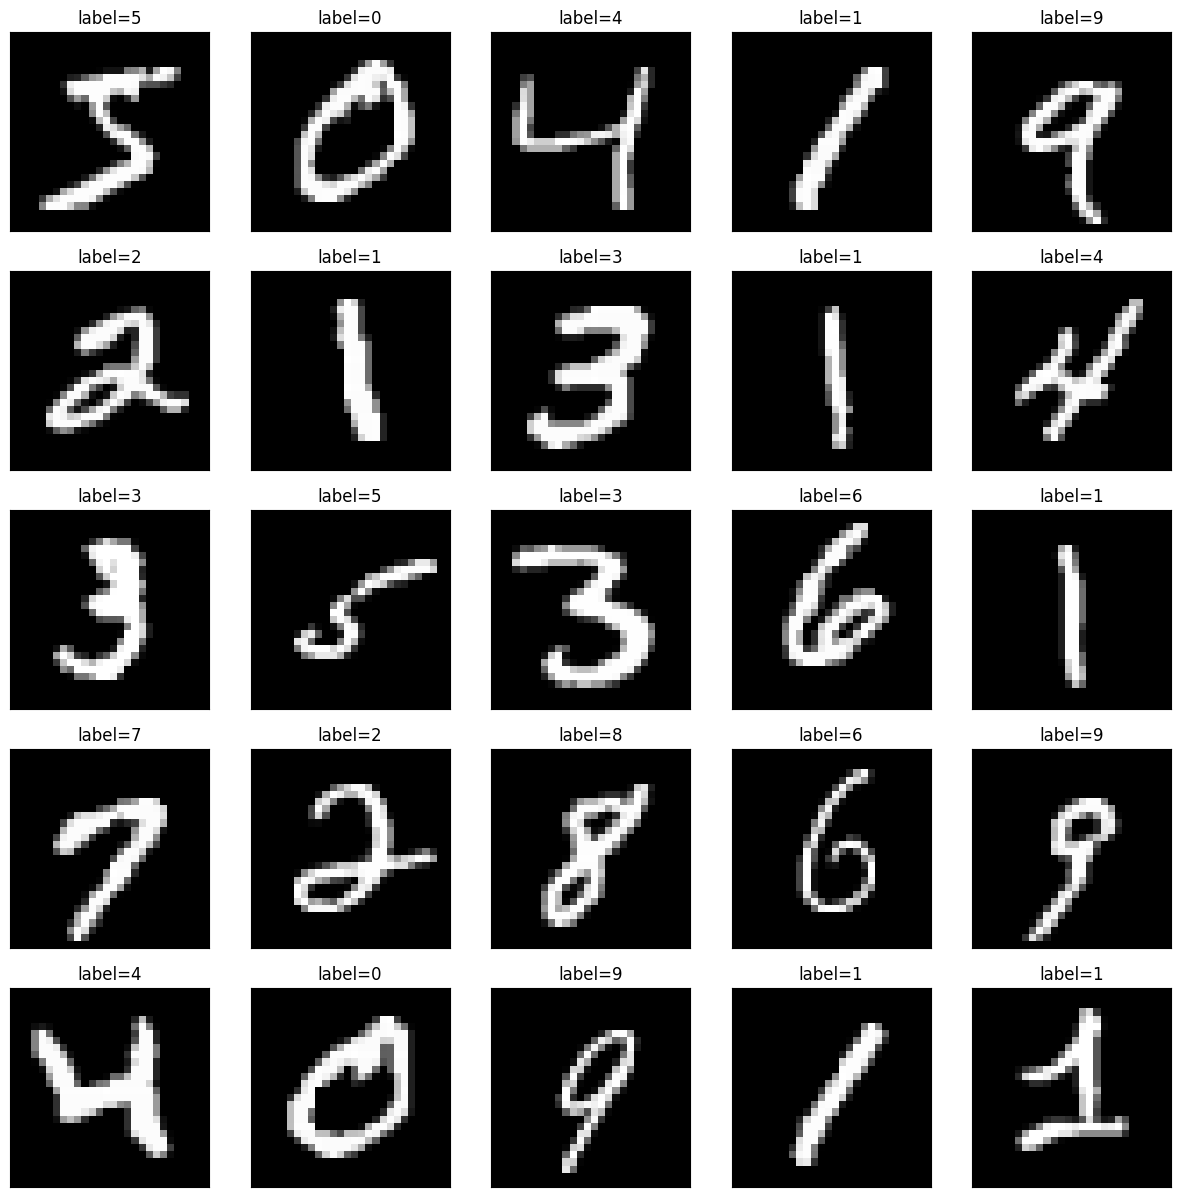

In [8]:
show_img_grid(
    [train_ds['image'][idx] for idx in range(25)],
    [f'label={train_ds["label"][idx]}' for idx in range(25)],
)

## Define our model

In [10]:
class ConvBlock(nn.Module):
    """A convolutional block consisting of a convolutional layer followed by ReLU and average pooling."""
    features: int

    @nn.compact
    def __call__(self, x):
        x = nn.Conv(features=self.features, kernel_size=(3, 3))(x)
        x = nn.relu(x)
        x = nn.avg_pool(x, window_shape=(2, 2), strides=(2, 2))
        return x

class Classifier(nn.Module):
    features: int

    @nn.compact
    def __call__(self, x):
        x = x.reshape((x.shape[0], -1))  # flatten
        
        x = nn.Dense(features=128)(x)
        x = nn.relu(x)
        x = nn.Dense(features=10)(x)

        return x

class CNN(nn.Module):
    """A deeper CNN model with modular convolutional blocks."""
    features: Sequence[int]
    
    def setup(self):
        layers = []
        for _, dim in enumerate(self.features):
            layers.append(
                ConvBlock(features=dim)
            )
        layers.append(Classifier(features=128))
        self.layers = tuple(layers)

    def __call__(self, x):
        self.sow('intermediates', f'layer_{0}_output', x)
        for i, layer in enumerate(self.layers):
            x = self.perturb(f'layer_{i+1}', x)
            x = layer(x)
            self.sow('intermediates', f'layer_{i+1}_output', x)

        return x

## First, basic train to get baseline 

We use SGD with no momentum. 

In [89]:
def train_model_sgd(train_ds, model, params, learning_rate, num_epochs,
                   bsz:int = 32):
    # Define the optimizer
    optimizer = optax.sgd(learning_rate)
    state = train_state.TrainState.create(
        apply_fn=model.apply, params=params['params'], tx=optimizer
    )

    @jax.jit
    def train_step(state, batch_X, labels):
        def loss_fn(params):
            logits = state.apply_fn(params, batch_X)
            one_hot = jax.nn.one_hot(labels, 10)
            loss = jnp.mean(optax.softmax_cross_entropy(logits=logits, labels=one_hot))
            return loss, logits

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (loss, logits), grads = grad_fn({'params': state.params})
        state = state.apply_gradients(grads=grads['params'])

        accuracy = jnp.mean(jnp.argmax(logits, -1) == labels)
        return state, loss, accuracy

    print(f"Starting training for {num_epochs} epochs...")
    
    train_ds_size = len(train_ds['image'])
    steps_per_epoch = train_ds_size // bsz

    rng = jax.random.PRNGKey(0)
    perms = jax.random.permutation(rng, len(train_ds['image']))
    perms = perms[: steps_per_epoch * bsz]  # skip incomplete batch
    perms = perms.reshape((steps_per_epoch, bsz))

    epoch_loss = []
    epoch_accuracy = []
    
    for _ in tqdm(range(num_epochs)):
        for perm in tqdm(perms):
            batch_images = train_ds['image'][perm, ...]
            batch_labels = train_ds['label'][perm, ...]

            state, loss, accuracy = train_step(state, batch_images, batch_labels)
            epoch_loss.append(loss)
            epoch_accuracy.append(accuracy)

    return state, epoch_loss, epoch_accuracy

num_epochs = 3

key = jax.random.PRNGKey(0)

model = CNN([4, 4, 4])
params = model.init(key, jnp.ones((1, 28, 28, 1)))
print(sum(x.size for x in jax.tree.leaves(params['params'])))
 
# Train the model
trained_state_sgd, sgd_losses, sgd_accuracy = train_model_sgd(
    train_ds, model, params, learning_rate=0.1, num_epochs=num_epochs, bsz=64
)

6362
Starting training for 3 epochs...


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

[<matplotlib.lines.Line2D at 0x7f5c72c51810>]

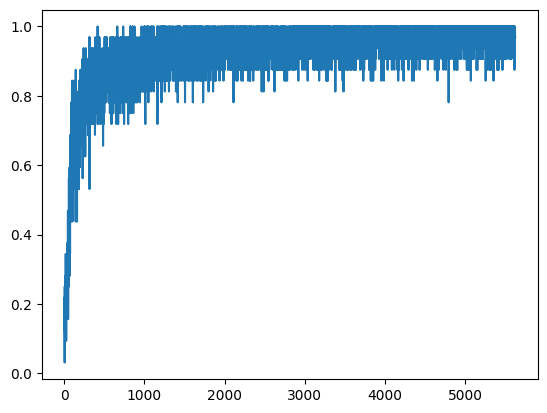

In [54]:
plt.plot(sgd_accuracy)

## Now, let's try a naive Gauss-Newton

We do 
1. Need to do adaptive tamping; B.3.1 from https://arxiv.org/pdf/1706.03662
2. Other people also do adaptive step size (B.2) from same paper.
3. Need better way to do layer by layer, since now they're somewhat different. 

In [95]:
def train_model_naive_precond(train_ds, model, params, learning_rate, num_epochs,
                   bsz:int = 64):
    # Define the optimizer
    optimizer = optax.sgd(learning_rate)
    state = train_state.TrainState.create(
        apply_fn=model.apply, params=params['params'], tx=optimizer
    )

    @jax.jit
    def train_step(state, batch_X, labels):
        one_hot = jax.nn.one_hot(labels, 10)
        def loss_fn(params):
            logits = state.apply_fn(params, batch_X)
            loss = jnp.mean(optax.softmax_cross_entropy(logits=logits, labels=one_hot))
            return loss, logits

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (loss, logits), grads = grad_fn({'params': state.params})

        jacobian = jax.jacobian(model.apply, argnums=0)(params, batch_X)['params']
        flattened, _ = jax.tree.flatten(
            jacobian
        )

        reshaped_leaves = [leaf.reshape(
            bsz * 10, 1, -1) for leaf in flattened]
        aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
        J = aggregated_array.reshape((bsz * 10, -1))
        
        # Generalized Gauss-Newton is J^THJ
        probs = jax.nn.softmax(logits, axis=-1).flatten()
        diag_probs = jnp.diag(probs)
        outer_probs = jnp.outer(probs, probs)
        H = diag_probs - outer_probs

        flattened, back = jax.flatten_util.ravel_pytree(grads)
        altered = jnp.linalg.solve(J.T @ H @ J + 0.1 *  jnp.eye(J.shape[1]), flattened)
        grads = back(altered)

        state = state.apply_gradients(grads=grads['params'])

        accuracy = jnp.mean(jnp.argmax(logits, -1) == labels)
        return state, loss, accuracy
    
    print(f"Starting training for {num_epochs} epochs...")
    
    train_ds_size = len(train_ds['image'])
    steps_per_epoch = train_ds_size // bsz

    rng = jax.random.PRNGKey(0)
    perms = jax.random.permutation(rng, len(train_ds['image']))
    perms = perms[: steps_per_epoch * bsz]  # skip incomplete batch
    perms = perms.reshape((steps_per_epoch, bsz))

    epoch_loss = []
    epoch_accuracy = []
    
    for _ in tqdm(range(num_epochs)):
        for perm in tqdm(perms):
            batch_images = train_ds['image'][perm, ...]
            batch_labels = train_ds['label'][perm, ...]

            state, loss, accuracy = train_step(state, batch_images, batch_labels)
            epoch_loss.append(loss)
            epoch_accuracy.append(accuracy)
            
    return state, epoch_loss, epoch_accuracy

num_epochs = 3

key = jax.random.PRNGKey(0)

model = CNN([4, 4, 4])
params = model.init(key, jnp.ones((1, 28, 28, 1)))
print(sum(x.size for x in jax.tree.leaves(params['params'])))
 
# Train the model
trained_state_precond, precond_losses, precond_accuracy = train_model_naive_precond(
    train_ds, model, params, learning_rate=0.05, num_epochs=num_epochs
)

6362
Starting training for 3 epochs...


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

[<matplotlib.lines.Line2D at 0x7f5b34792210>]

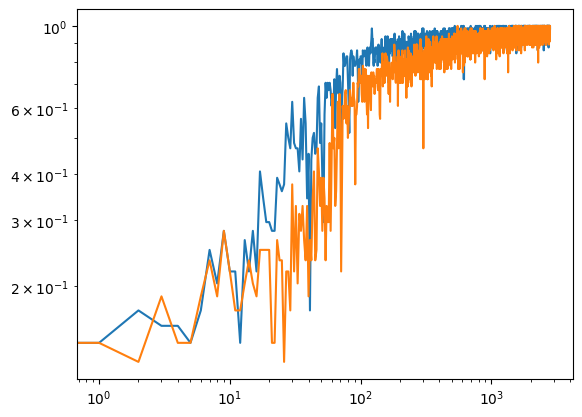

In [101]:
plt.loglog(precond_accuracy[:])
plt.loglog(sgd_accuracy[:])

[<matplotlib.lines.Line2D at 0x7f5b583b7750>]

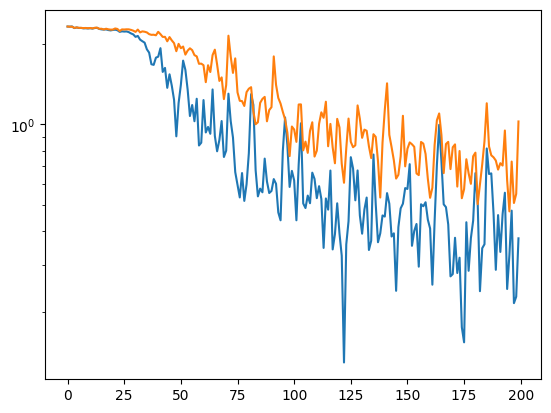

In [97]:
plt.semilogy(precond_losses[0:200])
plt.semilogy(sgd_losses[0:200])

[<matplotlib.lines.Line2D at 0x7f5b5823f390>]

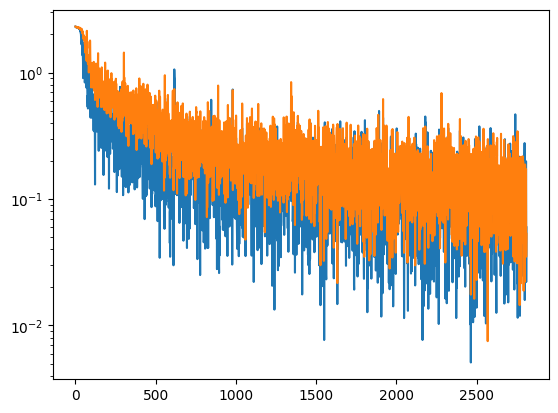

In [99]:
plt.semilogy(precond_losses[0:])
plt.semilogy(sgd_losses[0:])

## Layer approach 

Okay, now the above seems to work. Let's go on to the layer version. 
We first need to define several functions. 

## Verify

First we try to reconstruct again 

In [110]:
# Construct and store Jacobian. 
model = CNN([4, 4, 4])
params = model.init(key, jnp.ones((1, 28, 28, 1)))
params, perturbations = params['params'], params['perturbations']

print(sum(x.size for x in jax.tree.leaves(params)))


n_samples = 5
jacobian = jax.jacobian(model.apply, argnums=0)(
    {'params': params, 'perturbation': perturbations}, train_ds['image'][0:5, ...])['params']
flattened, _ = jax.tree.flatten(
    jacobian
)

# Reshape each leaf to (n_samples, n, -1) to flatten the parameter dimensions
reshaped_leaves = [leaf.reshape(n_samples * 10, 1, -1) for leaf in flattened]
aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
J = aggregated_array.reshape((n_samples * 10, -1))
treescope.display(J)


6362


In [112]:
global_adjoints = []
X =  train_ds['image'][0:5, ...]

# To grab the gradient wrt to the adjoints/residuals, we take the Jacobian wrt to the perturbations!
jacobian = jax.jacobian(
    lambda params, perturbations, X: model.apply({'params': params, 'perturbations': perturbations}, X), argnums=1
)(params, perturbations, X)
flattened, _ = jax.tree.flatten(
    jacobian
)
# It's weird that the perturbations are this dimensions, but it's easy to reshape them to what we need
together = [jnp.squeeze(leaf, axis=2).reshape((leaf.shape[0] * leaf.shape[1], -1)) for leaf in flattened]
global_adjoints = [
    block_diag(*jnp.split(leaf, n_samples, axis=0)) for leaf in together
]

global_adjoints.append(jnp.eye(J.shape[0]))


In [116]:
global_adjoints

[<jax.Array float64(50, 3920) ≈-7.5e-06 ±0.00042 [≥-0.011, ≤0.0065] zero:179_060 nonzero:16_940
   <Arrayviz rendering>
 | Device: GPU 0>,
 <jax.Array float64(50, 3920) ≈-2.6e-05 ±0.00099 [≥-0.021, ≤0.016] zero:163_400 nonzero:32_600
   <Arrayviz rendering>
 | Device: GPU 0>,
 <jax.Array float64(50, 980) ≈8.8e-06 ±0.0066 [≥-0.076, ≤0.079] zero:39_320 nonzero:9_680
   <Arrayviz rendering>
 | Device: GPU 0>,
 <jax.Array float64(50, 180) ≈-0.00048 ±0.052 [≥-0.36, ≤0.5] zero:7_200 nonzero:1_800
   <Arrayviz rendering>
 | Device: GPU 0>,
 <jax.Array float64(50, 50) ≈0.02 ±0.14 [≥0.0, ≤1.0] zero:2_450 nonzero:50
   <Arrayviz rendering>
 | Device: GPU 0>]

In [130]:
prediction, intermediates = model.apply({'params': params}, X, mutable=['intermediates'])

def get_layer_params(params: dict, layer_num: int, intermediates: jnp.ndarray):
    """
    Given the CNN above, grab layer derivatives 
    """
    layer = ConvBlock(features=4)
    
    def apply_layer(params):
        return layer.apply(
            params,
            intermediates['intermediates'][f'layer_{layer_num}_output'][0]
        )
        
    k_i = jax.jacrev(apply_layer)
    flattened, _ = jax.tree.flatten(
            k_i({'params': params[f'layers_{layer_num}']})
    )
    treescope.display(flattened)
    # reshaped_leaves = [leaf.reshape(leaf.shape[0] * leaf.shape[1], -1) for leaf in flattened]
    reshaped_leaves = [leaf.reshape(5 * 14*14*4, -1) for leaf in flattened]
    aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1) #.reshape(n * n_samples, -1)

    return aggregated_array

# print(model.features)
# print(params[f'layers_{0}'])
get_layer_params(params, 0, intermediates)

<jax.Array float32(3920, 40) ≈0.027 ±0.13 [≥0.0, ≤1.0] zero:148_229 nonzero:8_571
  <Arrayviz rendering>
| Device: GPU 0>

In [138]:
params.keys()

dict_keys(['layers_0', 'layers_1', 'layers_2', 'layers_3'])

In [122]:
treescope.display(intermediates['intermediates'])

## I think I need to redo my Jacobian calculating function first for CNNs; need to make it more efficient

In [106]:
def train_model_precond(train_ds, model, params, learning_rate, num_epochs,
                   bsz:int = 64):
    # Define the optimizer
    optimizer = optax.sgd(learning_rate)
    state = train_state.TrainState.create(
        apply_fn=model.apply, params=params['params'], tx=optimizer
    )

    # @jax.jit
    def train_step(state, batch_X, labels):
        one_hot = jax.nn.one_hot(labels, 10)
        def loss_fn(params):
            logits = state.apply_fn(params, batch_X)
            loss = jnp.mean(optax.softmax_cross_entropy(logits=logits, labels=one_hot))
            return loss, logits

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (loss, logits), grads = grad_fn({'params': state.params})

        jacobian = jax.jacobian(
            lambda params, perturbations, batch_X:
                state.apply_fn({'params': params, 'perturbations': perturbations}, batch_X), argnums=1
        )(state.params, params['perturbations'], batch_X)
        flattened, _ = jax.tree.flatten(
            jacobian
        )
        together = [jnp.squeeze(leaf, axis=2).reshape((leaf.shape[0] * leaf.shape[1], -1)) for leaf in flattened]
        global_adjoints = [
            block_diag(*jnp.split(leaf, len(batch_X), axis=0)) for leaf in together
        ]
        global_adjoints.append(jnp.eye(batch_X.shape[0]))

        treescope.display(global_adjoints)
        state = state.apply_gradients(grads=grads['params'])
        accuracy = jnp.mean(jnp.argmax(logits, -1) == labels)
        return state, loss, accuracy
    
    print(f"Starting training for {num_epochs} epochs...")
    
    train_ds_size = len(train_ds['image'])
    steps_per_epoch = train_ds_size // bsz

    rng = jax.random.PRNGKey(0)
    perms = jax.random.permutation(rng, len(train_ds['image']))
    perms = perms[: steps_per_epoch * bsz]  # skip incomplete batch
    perms = perms.reshape((steps_per_epoch, bsz))

    epoch_loss = []
    epoch_accuracy = []
    
    for _ in tqdm(range(num_epochs)):
        for perm in tqdm(perms):
            batch_images = train_ds['image'][perm, ...]
            batch_labels = train_ds['label'][perm, ...]

            state, loss, accuracy = train_step(state, batch_images, batch_labels)
            epoch_loss.append(loss)
            epoch_accuracy.append(accuracy)
            break
    return state, epoch_loss, epoch_accuracy

num_epochs = 1

key = jax.random.PRNGKey(0)

model = CNN([4, 4, 4])
params = model.init(key, jnp.ones((1, 28, 28, 1)))
print(sum(x.size for x in jax.tree.leaves(params['params'])))
 
# Train the model
trained_state_precond, precond_losses, precond_accuracy = train_model_precond(
    train_ds, model, params, learning_rate=0.05, num_epochs=num_epochs
)

6362
Starting training for 1 epochs...


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]